In [1]:
from  sklearn.datasets import load_sample_images
import tensorflow  as tf 

ModuleNotFoundError: No module named 'tensorflow'

In [2]:
import sys
print(sys.executable)

c:\Users\USER\envs\myml_env\Scripts\python.exe


In [3]:
load_sample_images()

{'images': [array([[[174, 201, 231],
          [174, 201, 231],
          [174, 201, 231],
          ...,
          [250, 251, 255],
          [250, 251, 255],
          [250, 251, 255]],
  
         [[172, 199, 229],
          [173, 200, 230],
          [173, 200, 230],
          ...,
          [251, 252, 255],
          [251, 252, 255],
          [251, 252, 255]],
  
         [[174, 201, 231],
          [174, 201, 231],
          [174, 201, 231],
          ...,
          [252, 253, 255],
          [252, 253, 255],
          [252, 253, 255]],
  
         ...,
  
         [[ 88,  80,   7],
          [147, 138,  69],
          [122, 116,  38],
          ...,
          [ 39,  42,  33],
          [  8,  14,   2],
          [  6,  12,   0]],
  
         [[122, 112,  41],
          [129, 120,  53],
          [118, 112,  36],
          ...,
          [  9,  12,   3],
          [  9,  15,   3],
          [ 16,  24,   9]],
  
         [[116, 103,  35],
          [104,  93,  31],
          [108

### Şəkilləri yükləmək və preprocess etmək

In [4]:

images =  load_sample_images()['images']
print(len(images))
images = tf.keras.layers.CenterCrop(height=70 , width=120)(images) # Şəkillərin mərkəzindən 70×120 ölçüdə kəsir
images = tf.keras.layers.Rescaling(scale=1 / 255) (images)  # 0–1 aralığına gətirir
images.shape 
# Netice
# TensorShape([2, 70, 120, 3])

# 2 - batch size,  yeni  2 sekil var
# 70 - hundurluyu , 120  -eni 
# 3 -kanal sayi (RGB)


2



TensorShape([2, 70, 120, 3])

### 2d  konvolusiya tebeqesi  yaradiriq


In [5]:

conv_layer = tf.keras.layers.Conv2D(filters= 32 ,   # 32 filt
                                    kernel_size=7  # filtr [7, 7] 
                                    )  
fmaps = conv_layer(images)
fmaps.shape  # TensorShape([2, 64, 114, 32])

# hundurluk - > (70 - 7 + 0) / 1 + 1 = 63 + 1 = 64
# en        - > (120 - 7 + 0) / 1 + 1 = 113 + 1 = 114
# feture map sayi = filter sayi =32 





TensorShape([2, 64, 114, 32])

### Padding (sıfır doldurma) 

In [6]:
conv_layer = tf.keras.layers.Conv2D(filters=32,
                                    kernel_size=7 , 
                                    padding ='same') # cixisla giris eyni  olcude olan sayda
fmaps = conv_layer(images)
fmaps.shape  #  padding sayi  3 olduguna gore giris cixila eyni  olcude

TensorShape([2, 70, 120, 32])

### Stride 

In [7]:
conv_layer = tf.keras.layers.Conv2D(filters=32,
                                    kernel_size=7, 
                                    strides = 2,
                                    padding='same'
                                    )
fmaps = conv_layer(images)
fmaps.shape

# hundurluk  (70 + 2*3 - 7)/2 + 1 = (70+6-7)/2 + 1 = 69/2 + 1 = 34.5 + 1 = 35.5 → tam hissə 35
# en  (120 + 6 - 7)/2 + 1 = 119/2 + 1 = 59.5 + 1 = 60.5 → 60



TensorShape([2, 35, 60, 32])

### Conv2D qatının çəkiləri (weights) və bias

In [8]:
kernels,biases = conv_layer.get_weights()
kernels.shape  # (7, 7, 3, 32)  [7,7] filter olcusu , 3 rgb , 32 filter sayi
biases.shape   # (32,) her filtr ucun  1 bias 


(32,)

### Pooling layers with  Keras

In [9]:
#  max pooling
max_pool = tf.keras.layers.MaxPool2D(pool_size=2) 
 # [2,2] olculu  kernel
# default  stride = 2 
# default  padding  = 'valid'   ->  no  padding
fmaps = max_pool(images)
print(fmaps.shape)



# average pooling
avg_pool = tf.keras.layers.AveragePooling2D(pool_size=2)
fmaps = avg_pool(images)
print(fmaps.shape)


# depthwise max pollling

# class DepthPool(tf.keras.layers.Layer):
#     def __init__(self,pool_size=2, **kwargs):
#         super().__init__(**kwargs)
#         self.pool_size = pool_size

#     def call(self, inputs):
#         shape = tf.shape(inputs)  # [batch, h, w, channels]
#         groups = shape[-1] // self.pool_size   # kanal sayi // pool_size = qaliq 1
#         new_shape = tf.concat([shape[:-1],
#                                [groups, self.pool_size]],axis =0)  # [batch, h, w, groups, pool_size]

#         return  tf.reduce_max(tf.reshape(inputs, new_shape),axis=-1)  # Hər qrupdan maksimum dəyəri götürür
# pool = DepthPool(pool_size=2)
# fmaps = pool(images)  # ✅ DÜZGÜN - instance-ı birbaşa çağırmaq
# print(fmaps.shape)

# Global Average Pooling
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()
fmaps = global_avg_pool(images)
print(fmaps.shape)

# ve ya 
global_avg_pool =tf.keras.layers.Lambda(lambda X:  tf.reduce_mean(X,axis=[1,2]))
fmaps= global_avg_pool(images)
print(fmaps.shape)


(2, 35, 60, 3)
(2, 35, 60, 3)
(2, 3)
(2, 3)


### CNN arxitekturasi

In [10]:
from functools import partial
import tensorflow as tf


DefaultConv2D = partial(
                        tf.keras.layers.Conv2D,
                        kernel_size=3,                  # 3×3 kernel
                        padding="same",                 # Ölçü qorunsun
                        activation="relu",              # ReLU aktivasiyası
                        kernel_initializer="he_normal"  # He normal initializer
                    )

model = tf.keras.Sequential([
    # BLOK 1 - Aşağı səviyyəli feature-lər (kənarlar, xətlər)
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28,28,1]), # 7×7 ilə başla
    tf.keras.layers.MaxPool2D(),                              # 28×28 → 14×14

    # BLOK 2 - Orta səviyyəli feature-lər (toxumalar, sadə formalar)
    DefaultConv2D(filters=128),  # 128 feature map
    DefaultConv2D(filters=128),  # daha dərin
    tf.keras.layers.MaxPool2D(), # 14×14 → 7×7

    # BLOK 3 - Yüksək səviyyəli feature-lər (göz, burun, qulaq...)
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    tf.keras.layers.MaxPool2D(), # 7×7 → 3×3 (təxmini)

    # Təsnifat hissəsi
    tf.keras.layers.Flatten(),                    # 3×3×256 → vektor
    tf.keras.layers.Dense(128,  activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),                  # Overfitting-i azalt
    tf.keras.layers.Dense(64,   activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10,   activation="softmax") # 10 sinif
])

### ResNet-34

In [11]:
DefaultConv2D = partial(tf.keras.layers.Conv2D,
                        kernel_size = 3, 
                        strides =1,
                        padding='same',
                        kernel_initializer='he_normal',
                        use_bias = False
                        )

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)  # aktivasiya teyin edilir ( relu )
        
        # Əsas yol (sağ tərəf) - 2 konvolusiya + BN
        self.main_layers = [
                            DefaultConv2D(filters, strides=strides),
                            tf.keras.layers.BatchNormalization(),
                            self.activation,
                            DefaultConv2D(filters),
                            tf.keras.layers.BatchNormalization()
                           ]
        
        # Skip connection yolu (sol tərəf) - yalnız stride > 1 olduqda
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]
    
    def call(self, inputs):
        # Əsas yoldan keçir
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        
        # Skip connection yolundan keçir (əgər varsa)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        
        # İki yolun çıxışını topla və aktivasiya tətbiq et
        return self.activation(Z + skip_Z)
    

model = tf.keras.Sequential([
    # Giriş hissəsi
    DefaultConv2D(64, kernel_size=7, strides=2, input_shape=[224, 224, 3]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"),
])

# Residual unit-lərin əlavə edilməsi
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3: #[64,64,64, 128,128,128,128,128, 256,256,256,256,256,256, 512,512,512]
    strides = 1 if filters == prev_filters else 2 #  filter sayi  artigina gore addim 2 defe artir ki  cixis olcsu azalsin yoxsa element sayi 2 defe  artar
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

# Son hissə
model.add(tf.keras.layers.GlobalAvgPool2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation="softmax"))


### ResNet 50  pretrained dataset


In [12]:
# ResNet-50 modelini ImageNet çəkiləri ilə yüklə
model = tf.keras.applications.ResNet50(weights="imagenet")
# Şəkilləri yüklə və ölçüsünü dəyiş
images = load_sample_images()["images"]
images_resized = tf.keras.layers.Resizing(
                                            height=224, 
                                            width=224,
                                            crop_to_aspect_ratio=True
                                        )(images)
#  ----------------------------------
# ResNet-50 üçün xüsusi preprocessing funksiyası.
inputs = tf.keras.applications.resnet50.preprocess_input(images_resized) 

# -----------------------------
Y_proba = model.predict(inputs)
print(Y_proba.shape)  # (2, 1000) → 2 şəkil, 1000 sinif

print('sekil olcusu',len(images))
# ----------------------
top_K = tf.keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for image_index in range(len(images)):
    print(f"Image #{image_index}")
    for class_id, name, y_proba in top_K[image_index]:
        print(f"  {class_id} - {name:12s} {y_proba:.2%}")


1/1 [==============================] - 2s 2s/step
(2, 1000)
sekil olcusu 2
Image #0
  n03877845 - palace       54.69%
  n03781244 - monastery    24.71%
  n02825657 - bell_cote    18.55%
Image #1
  n04522168 - vase         32.67%
  n11939491 - daisy        17.82%
  n03530642 - honeycomb    12.04%


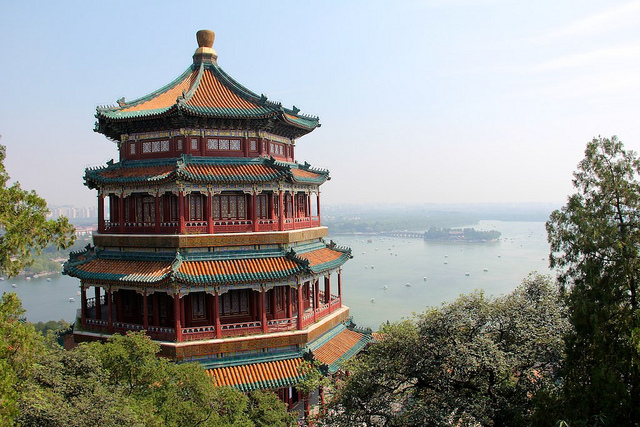

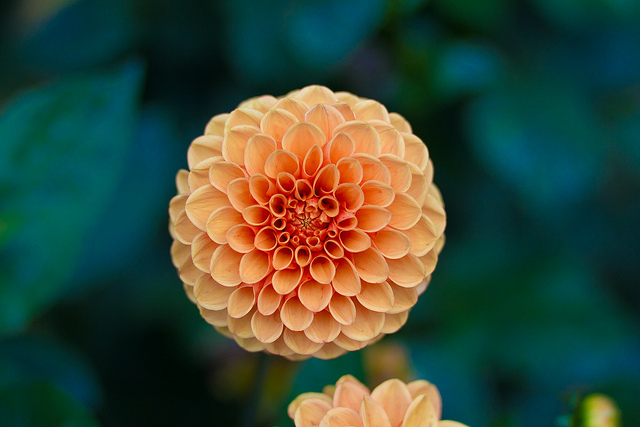

In [13]:
#   Sekillere baxmaq ucun
for i, img in enumerate(images):
    display(tf.keras.preprocessing.image.array_to_img(img))

### Transfer Learning üçün Hazır Modellər

In [14]:
import tensorflow_datasets as tfds


# "tf_flowers" datasetini yüklə
dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
# print('\n',info)

# Dataset haqqında məlumat
dataset_size = info.splits["train"].num_examples      # 3670 şəkil
print(dataset_size)
class_names  = info.features["label"].names            # ["dandelion", "daisy", ...]
print(class_names)
n_classes    = info.features["label"].num_classes        # 5 sinif
print(n_classes)


# Train/Validation/Test Bölgüsü
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
                        "tf_flowers",
                        split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
                        as_supervised=True
                    )

print('test data {} \nvalid data {} \ntrain data {}'.format(len(test_set_raw), len(valid_set_raw),len(train_set_raw)))

3670
['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
5
test data 367 
valid data 551 
train data 2752


In [ ]:

# Preprocessing

batch_size = 32

preprocess = tf.keras.Sequential([
    # Şəkilləri 224×224-ə ölçüləndir (Xception üçün uyğun)
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True), # sekili olcusun deyisisr ve qiraqda artiqlari kecir 
    # Xception-un gözlədiyi formata çevir (piksellər -1...1 arası)
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)  # [-1,1 ] araligina getirir avtomatik
])

# Hər dataset-ə preprocessing tətbiq et
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))         #  X-i [-1,1]  araligina getirir, y qalir
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)  
# Hər dəfə batch yaradanda bu 1000 şəkildən təsadüfi  batch_size qeder  seçir
# prefetch(1) - gpu-cpu  istifadesin  paralel apar , yoxsa cpu bacth 1 in bitmeyin gozleyer sonra batch 2 hazirlanar , yeni  arada gpu  bos qalar


valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set  = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)


In [ ]:
# Data Augmentation 

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),        #  soldan sağa çevirir (güzgü effekti)
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),          # sağa və ya sola azca döndərir
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)            # kontrastını (parlaqlıq fərqini) dəyişir
])


In [ ]:
# ImageNet-də təlim edilmiş Xception-u yüklə, üst qatları olmadan
base_model = tf.keras.applications.xception.Xception(
    weights="imagenet",         # Modelin ImageNet datasetində təlim edilmiş çəkilərini yükləyir
    include_top=False           # GlobalAveragePooling və Dense qatları yoxdur , False olandə son təsnifat qatları yüklənmir
    # (Input(224,224,3) → Xception feature extractor → novbeti qatlar yuklenmir)
)
print(base_model.output)
print(base_model.input)

avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)    # Base modelin çıxışını al
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg) # Öz sıx qatımızı əlavə et (5 sinif üçün)

# Tam modeli yarat
model = tf.keras.Model(inputs=base_model.input, outputs=output)

<KerasTensor: shape=(None, None, None, 2048) dtype=float32 (created by layer 'block14_sepconv2_act')>

In [ ]:

# print(base_model.layers)
for layer in base_model.layers:
    # print(layer.trainable)
    layer.trainable = False   # model base hisseye (xception)toxunmur ancaq sonradan elave edilen bziim terefimizden GlobalAveragePooling və Dense qatları oyredib cekiler yaradir 

optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3
86/86 [==============================] - 61s 683ms/step - loss: 0.6193 - accuracy: 0.8201 - val_loss: 0.6469 - val_accuracy: 0.8294
Epoch 2/3
86/86 [==============================] - 54s 631ms/step - loss: 0.3201 - accuracy: 0.9070 - val_loss: 0.5916 - val_accuracy: 0.8494
Epoch 3/3
86/86 [==============================] - 60s 695ms/step - loss: 0.2958 - accuracy: 0.9128 - val_loss: 0.6217 - val_accuracy: 0.8711


In [28]:
# 56-cı laydan sonrakıları təlim edilə bilən et
for layer in base_model.layers[56:]:
    print(layer)
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)


In [ ]:

history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/3



86/86 [==============================] - 81s 873ms/step - loss: 0.6872 - accuracy: 0.8110 - val_loss: 0.6336 - val_accuracy: 0.8403
Epoch 2/3
86/86 [==============================] - 68s 785ms/step - loss: 0.3058 - accuracy: 0.9132 - val_loss: 0.5427 - val_accuracy: 0.8693
Epoch 3/3
86/86 [==============================] - 60s 698ms/step - loss: 0.2113 - accuracy: 0.9317 - val_loss: 0.5828 - val_accuracy: 0.8657
Epoch 1/10
86/86 [==============================] - 141s 2s/step - loss: 0.2679 - accuracy: 0.9052 - val_loss: 0.5775 - val_accuracy: 0.8512
Epoch 2/10
86/86 [==============================] - 140s 2s/step - loss: 0.0624 - accuracy: 0.9840 - val_loss: 0.3860 - val_accuracy: 0.9093
Epoch 3/10
86/86 [==============================] - 183s 2s/step - loss: 0.0145 - accuracy: 0.9964 - val_loss: 0.3409 - val_accuracy: 0.9129
Epoch 4/10
86/86 [==============================] - 318s 4s/step - loss: 0.0089 - accuracy: 0.9971 - val_loss: 0.2963 - val_accuracy: 0.9147
Epoch 5/10
86/86 [==

### Classification + Localization

In [ ]:
base_model = tf.keras.applications.xception.Xception(
    weights="imagenet",    # ImageNet-də təlim edilmiş Xception modelini yüklə (üst qatlarsız)
    include_top=False      # Təsnifat qatları olmadan
)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output) # Base modelin çıxışını götür

# --- TƏSNİFAT + LOKALİZASİYA HİSSƏSİ ---

# 1. Çıxış: Təsnifat üçün (5 sinif)
class_output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)

# 2. Çıxış: Lokalizasiya üçün (4 koordinat: x, y, w, h)
loc_output = tf.keras.layers.Dense(4)(avg)  # activation yoxdur (reqressiya)

# İki çıxışlı modeli yarat
model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[class_output, loc_output]  # Həm təsnifat, həm lokalizasiya çıxışı
)


for layer in base_model.layers:
    layer.trainable = False      # Base modelin qatlarını dondur (transfer learning)

optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)   # Optimizer seç (SGD - Stochastic Gradient Descent)
  
# Modeli kompilyasiya et (İKİ LOSS ilə!)
model.compile(
                loss=["sparse_categorical_crossentropy", "mse"],  # təsnifat loss, reqressiya loss
                loss_weights=[0.8, 0.2],                         # təsnifat 80%, lokalizasiya 20% önəm verir
                optimizer=optimizer, 
                metrics=["accuracy"]                            # təsnifat dəqiqliyini izlə
            )

# Modeli təlim et (qeyd: dataset-də bounding box yoxdur, bu sadəcə struktur nümunəsidir)

# history = model.fit(train_set, validation_data=valid_set, epochs=3)


# --- QEYD: Bu dataset-də bounding box məlumatı olmadığı üçün təlim işləməyəcək. Bu kod sadəcə struktur nümunəsidir.  Real tətbiq üçün bounding box etiketləri lazımdır!
# tf.keras.metrics.MeanIoU(num_classes=1)  # bounding box üçün


### 